In [2]:
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
#from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

Aca importamos un dataset que armamos anteriormente en otro otebook. Vamos a hacer una prediccion de la estacion de destino de la bicicleta para la estación de origen constitución.

Acá hicimos anteriormente transformaciones sobre la fecha, obteniendo diferentes columnas de dia, mes año. Además, obtuvimos un dataset de temperatura, precipitaciones y viento, para generar un posible indice que nos mejore la predicción.

In [2]:
"year_key", "month_of_year", "day_of_month" , "iso_day_of_week", "estacion_origen", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd"

('year_key',
 'month_of_year',
 'day_of_month',
 'iso_day_of_week',
 'estacion_origen',
 'estacion_destino',
 'grupo_edad',
 'tavg',
 'prcp',
 'wspd')

In [3]:
df = pd.read_parquet("dataset_general.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df.to_parquet("dataset_resumido.parquet")

In [38]:
df = pd.read_parquet("dataset_general.parquet")
df = df[ df["estacion_origen"] == '236 - UBA SOCIALES']
df["hora"] = df["fecha_origen_recorrido"].dt.hour
df = df.drop(columns=["estacion_origen", "year_key","fecha_origen_recorrido", "fecha_destino_recorrido", "date_key", "date", "first_day_of_week", "last_day_of_week",
                      "first_day_of_month", "last_day_of_month", "first_day_of_quarter", "last_day_of_quarter", "first_day_of_year", "last_day_of_year"])
#df['fecha_origen_recorrido'] = pd.to_datetime(df['fecha_origen_recorrido']).astype('datetime64[s]')
#df['fecha_destino_recorrido'] = pd.to_datetime(df['fecha_destino_recorrido']).astype('datetime64[s]')
#df['date_key'] = pd.to_datetime(df['date_key']).astype('datetime64[s]')
#df['date'] = pd.to_datetime(df['date']).astype('datetime64[s]')

In [5]:
df.columns

Index(['duracion_estim_seg', 'modelo_bicicleta', 'estacion_destino',
       'genero_usuario', 'edad_usuario', 'day_of_year', 'week_key',
       'week_of_year', 'day_of_week', 'iso_day_of_week', 'day_name',
       'first_day_of_week', 'last_day_of_week', 'month_key', 'month_of_year',
       'day_of_month', 'month_name_short', 'month_name', 'first_day_of_month',
       'last_day_of_month', 'quarter_key', 'quarter_of_year', 'day_of_quarter',
       'quarter_desc_short', 'quarter_desc', 'first_day_of_quarter',
       'last_day_of_quarter', 'first_day_of_year', 'last_day_of_year',
       'ordinal_weekday_of_month', 'tavg', 'prcp', 'wspd'],
      dtype='object')

para hacer el analisis vamos a hacerlo sobre la estación de la uba de sociales

In [13]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,day_of_year,week_key,week_of_year,day_of_week,iso_day_of_week,...,quarter_desc_short,quarter_desc,first_day_of_quarter,last_day_of_quarter,first_day_of_year,last_day_of_year,ordinal_weekday_of_month,tavg,prcp,wspd
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1721,926,FIT,064 - RIOBAMBA,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
2536,592,ICONIC,084 - TEATRO PICADERO,MALE,29,291,202442,42,4,4,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,299,202443,43,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,22.6,3.3,6.7
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,302,202444,44,1,1,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,24.4,0.0,8.2
3500462,821,FIT,179 - CASA SAN,MALE,19,300,202443,43,6,6,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,16.9,0.0,4.7
3500495,385,FIT,008 - Congreso,MALE,62,300,202443,43,6,6,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,16.9,0.0,4.7


Para analizar desbalanceo de la variable de salida, vamos a ver la cantidad de salida de las 30 estaciones de destino mas grandes

In [18]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]

<Axes: xlabel='percent', ylabel='estacion_destino'>

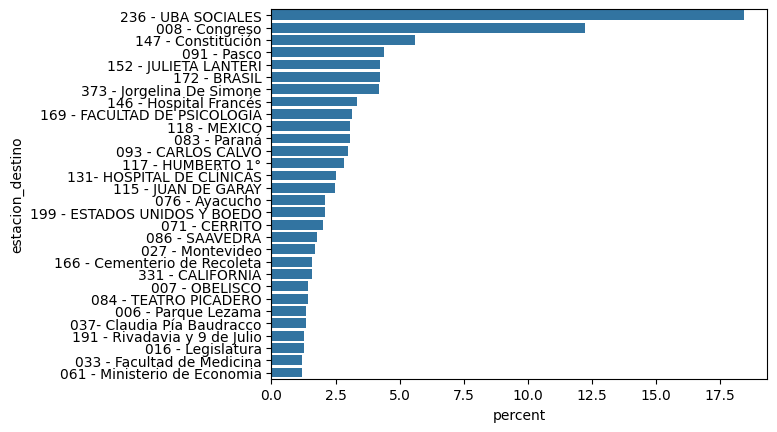

In [8]:
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')

Podemos ver como en general las clases presentan una distribucion medianamente uniforme descendente, salvo por dos casos atipicos: la misma estación de uba sociales, y la estación de congreso. Vamos a ver metodologías para corregir estos desbalanceos. Consideramos que para este caso, puede existir un desbalance natural de la información, que no necesariamente es malo, ya que muestra la mayor frecuencia de utilización del transporte. Como criterio, vamos a retirar la clase mayoritaria, debido a que a fines analiticos, no podemos obtener mucha información de un viaje que salió y llegó a la misma estación.

In [9]:
df = df[df['estacion_destino']!= '236 - UBA SOCIALES']

<Axes: xlabel='percent', ylabel='estacion_destino'>

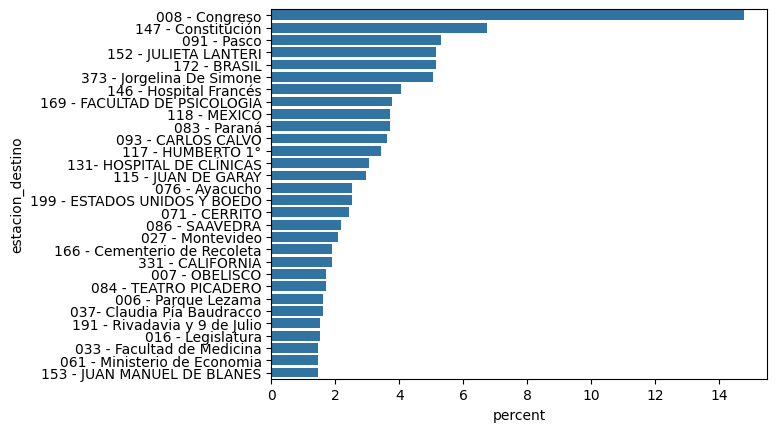

In [10]:
# Get the top 20 categories by count
top_30 = df['estacion_destino'].value_counts().nlargest(30).index

# Filter the DataFrame to only include these top 20 categories
df_top30 = df[df['estacion_destino'].isin(top_30)]
sns.countplot(df_top30, y="estacion_destino", order=top_30, stat='percent')


In [11]:
df

,duracion_estim_seg,modelo_bicicleta,estacion_destino,genero_usuario,edad_usuario,day_of_year,week_key,week_of_year,day_of_week,iso_day_of_week,...,quarter_desc_short,quarter_desc,first_day_of_quarter,last_day_of_quarter,first_day_of_year,last_day_of_year,ordinal_weekday_of_month,tavg,prcp,wspd
622,832,FIT,131- HOSPITAL DE CLÍNICAS,MALE,31,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1721,926,FIT,064 - RIOBAMBA,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1736,1736,FIT,286 - FILOSOFIA Y LETRAS,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
1948,816,ICONIC,041 - PARQUE PATRICIOS II,None,<NA>,292,202442,42,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,21.1,0.0,8.9
2536,592,ICONIC,084 - TEATRO PICADERO,MALE,29,291,202442,42,4,4,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,3,26.6,0.5,7.1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3495632,490,ICONIC,073 - Ruy Díaz de Guzmán,None,<NA>,299,202443,43,5,5,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,22.6,3.3,6.7
3500105,683,ICONIC,152 - JULIETA LANTERI,MALE,33,302,202444,44,1,1,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,24.4,0.0,8.2
3500462,821,FIT,179 - CASA SAN,MALE,19,300,202443,43,6,6,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,16.9,0.0,4.7
3500495,385,FIT,008 - Congreso,MALE,62,300,202443,43,6,6,...,Q4,Quarter 4,2024-10-01,2024-12-31,2024-01-01,2024-12-31,4,16.9,0.0,4.7


Otra metodología que puede llegarse a utilizar en este caso es la de underfitting de la categoría mayoritaria: retirar muestras de la estación de congreso:

In [53]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

In [38]:
# Undersampling
undersample = RandomUnderSampler(random_state=42)
X_train_us, y_train_us = undersample.fit_resample(X_train, y_train)

In [39]:
X_train_us

,year_key,month_of_year,day_of_month,iso_day_of_week,estacion_origen,tavg,prcp,wspd
109652,2024,12,17,2,236 - UBA SOCIALES,23.3,9.9,9.3
2430537,2024,10,11,5,236 - UBA SOCIALES,22.3,0.0,6.6
2102863,2024,11,1,5,236 - UBA SOCIALES,25.9,0.0,11.7
332267,2024,12,6,5,236 - UBA SOCIALES,23.7,14.0,9.6
1764362,2024,11,15,5,236 - UBA SOCIALES,26.5,0.0,10.5
...,...,...,...,...,...,...,...,...
2458053,2024,10,8,2,236 - UBA SOCIALES,20.8,0.0,9.7
3380547,2024,10,16,3,236 - UBA SOCIALES,20.6,0.0,6.8
1963559,2024,11,30,6,236 - UBA SOCIALES,21.7,0.0,8.9
1247498,2024,11,6,3,236 - UBA SOCIALES,21.7,0.0,11.3


In [46]:
X

,year_key,month_of_year,day_of_month,iso_day_of_week,tavg,prcp,wspd
622,2024,10,18,5,21.1,0.0,8.9
1721,2024,10,18,5,21.1,0.0,8.9
1736,2024,10,18,5,21.1,0.0,8.9
1948,2024,10,18,5,21.1,0.0,8.9
2536,2024,10,17,4,26.6,0.5,7.1
...,...,...,...,...,...,...,...
3495632,2024,10,25,5,22.6,3.3,6.7
3500105,2024,10,28,1,24.4,0.0,8.2
3500462,2024,10,26,6,16.9,0.0,4.7
3500495,2024,10,26,6,16.9,0.0,4.7


Ahora vamos a empezar a realizar analisis entre varaibles:

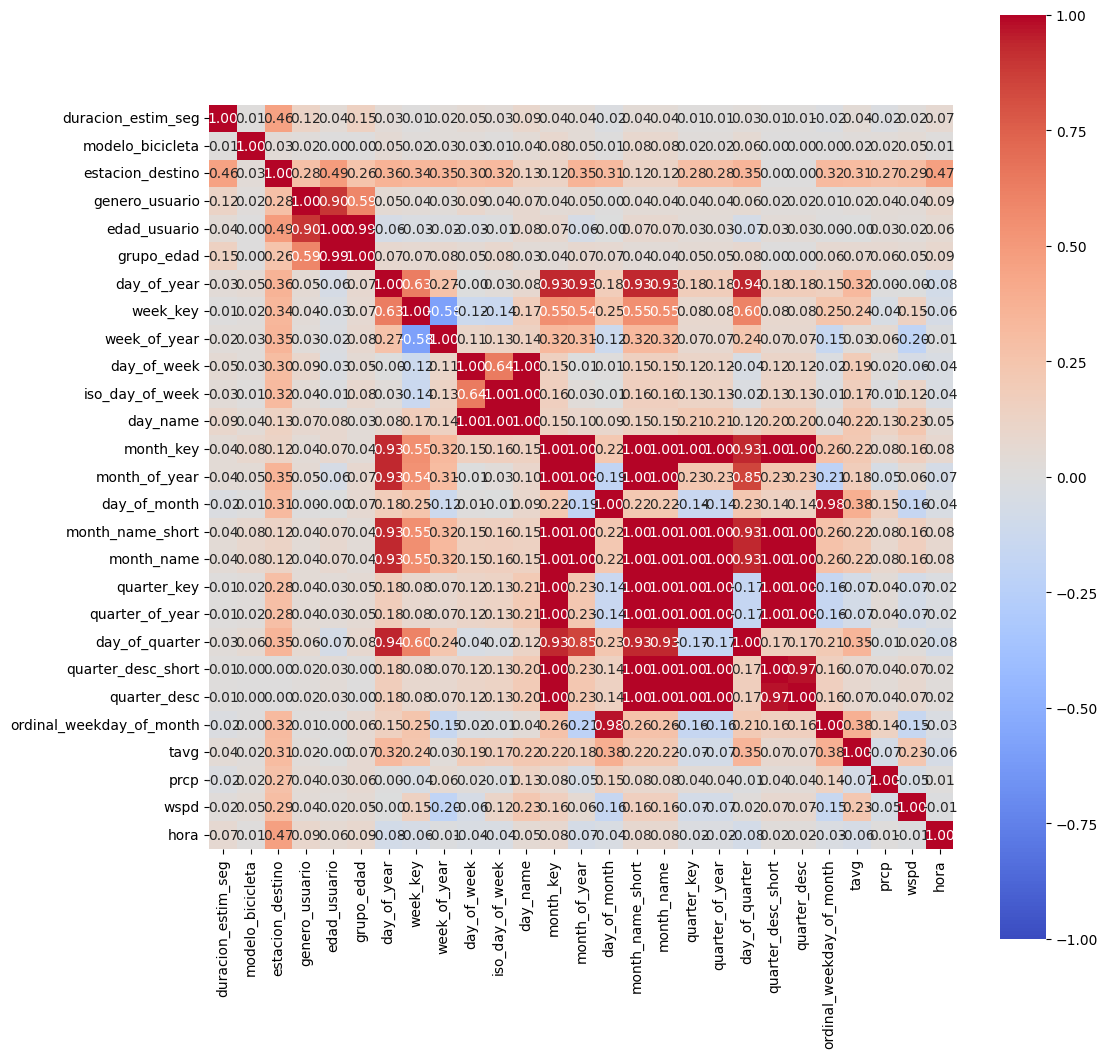

{'corr':                           duracion_estim_seg  modelo_bicicleta  \
 duracion_estim_seg                  1.000000          0.013514   
 modelo_bicicleta                    0.013514          1.000000   
 estacion_destino                    0.456164          0.032550   
 genero_usuario                      0.118371          0.019530   
 edad_usuario                        0.043950          0.004375   
 grupo_edad                          0.147337          0.000000   
 day_of_year                         0.032918          0.048129   
 week_key                            0.006870          0.017012   
 week_of_year                        0.023857          0.030584   
 day_of_week                         0.053741          0.027610   
 iso_day_of_week                     0.033230          0.012299   
 day_name                            0.088630          0.042041   
 month_key                           0.041749          0.082157   
 month_of_year                       0.041120         

In [39]:
from dython.nominal import associations
import matplotlib.pyplot as plt
# Calcular asociaciones para todas las variables
associations(df, figsize=(12, 12), cmap='coolwarm')


Esta funcion nos permite ver una matriz de correlación tanto para variables numericas como categoricas. Esto nos ayuda a ver que las variables principales de análisis son:
"month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino", "grupo_edad", "tavg", "prcp", "wspd" y edad usuario.

Debido a la cantidad de falta de datos, eliminamos también la variable de edad usuario, grupo edad.


In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2148 entries, 622 to 3500626
Data columns (total 26 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   duracion_estim_seg        2148 non-null   int64  
 1   modelo_bicicleta          2148 non-null   object 
 2   estacion_destino          2148 non-null   object 
 3   genero_usuario            951 non-null    object 
 4   edad_usuario              951 non-null    Int64  
 5   grupo_edad                951 non-null    object 
 6   day_of_year               2148 non-null   int64  
 7   week_key                  2148 non-null   int64  
 8   week_of_year              2148 non-null   int64  
 9   day_of_week               2148 non-null   int64  
 10  iso_day_of_week           2148 non-null   int64  
 11  day_name                  2148 non-null   object 
 12  month_key                 2148 non-null   object 
 13  month_of_year             2148 non-null   int64  
 14  day_of_m

In [41]:
df = df[["month_of_year", "day_of_month" , "iso_day_of_week", "estacion_destino","hora", "tavg", "prcp", "wspd"]]

In [42]:
df

,month_of_year,day_of_month,iso_day_of_week,estacion_destino,hora,tavg,prcp,wspd
622,10,18,5,131- HOSPITAL DE CLÍNICAS,17,21.1,0.0,8.9
1721,10,18,5,064 - RIOBAMBA,13,21.1,0.0,8.9
1736,10,18,5,286 - FILOSOFIA Y LETRAS,17,21.1,0.0,8.9
1948,10,18,5,041 - PARQUE PATRICIOS II,12,21.1,0.0,8.9
2450,10,18,5,236 - UBA SOCIALES,17,21.1,0.0,8.9
...,...,...,...,...,...,...,...,...
3495632,10,25,5,073 - Ruy Díaz de Guzmán,15,22.6,3.3,6.7
3500105,10,28,1,152 - JULIETA LANTERI,8,24.4,0.0,8.2
3500462,10,26,6,179 - CASA SAN,13,16.9,0.0,4.7
3500495,10,26,6,008 - Congreso,19,16.9,0.0,4.7


Ademas de ello, vamos a generar un indice que combine todas las métricas climaticas, para evaluar su desempeño:

<Axes: xlabel='tavg', ylabel='Count'>

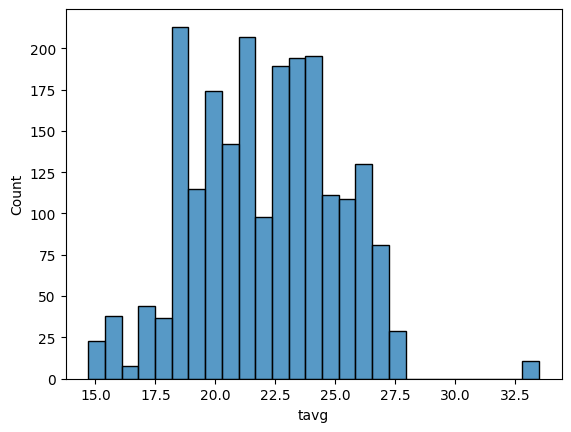

In [47]:
sns.histplot(df, x="tavg")

standart scaler

<Axes: xlabel='wspd', ylabel='Count'>

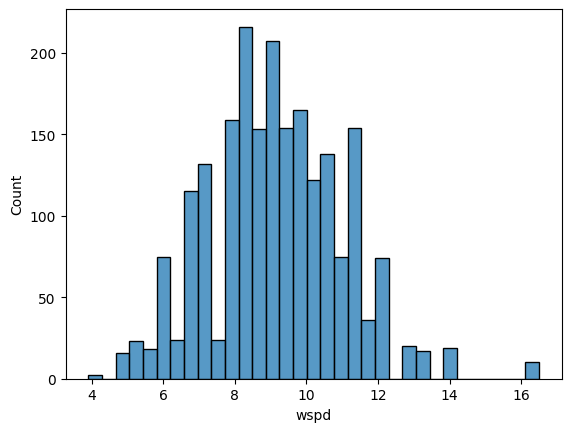

In [43]:
sns.histplot(df, x="wspd")

esta la escalamos con standart scaler

<Axes: xlabel='prcp', ylabel='Count'>

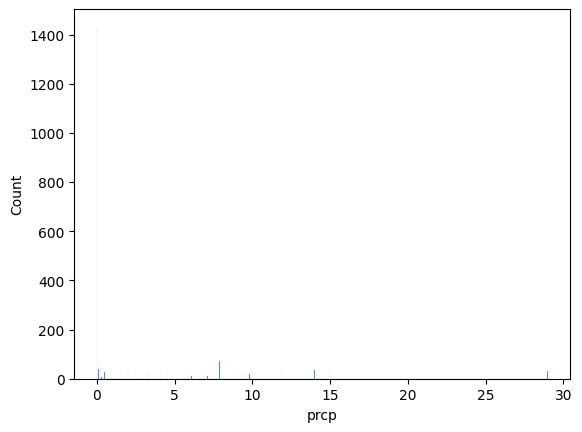

In [46]:
sns.histplot(df, x="prcp")

Esta la escalamos con normalizacion min max

In [32]:
df['norm_temp'] = (df['tavg'] - 10) / (25 - 10)  # 10°C (cold) to 25°C (ideal)
df['norm_precip'] = 1 - (df['prcp'] / 10).clip(0, 1)  # 0mm (ideal) to 10mm+ (bad)
df['norm_wind'] = 1 - (df['wspd'] / 30).clip(0, 1)  # 0km/h (ideal) to 30km/h+ (bad)

df['cycling_score'] = (
    0.5 * df['norm_temp'] +
    0.3 * df['norm_precip'] +
    0.2 * df['norm_wind']
)

Generamos indicador de fin de semana:

In [36]:
df["is_weekend"] = df["iso_day_of_week"].isin([6,7])

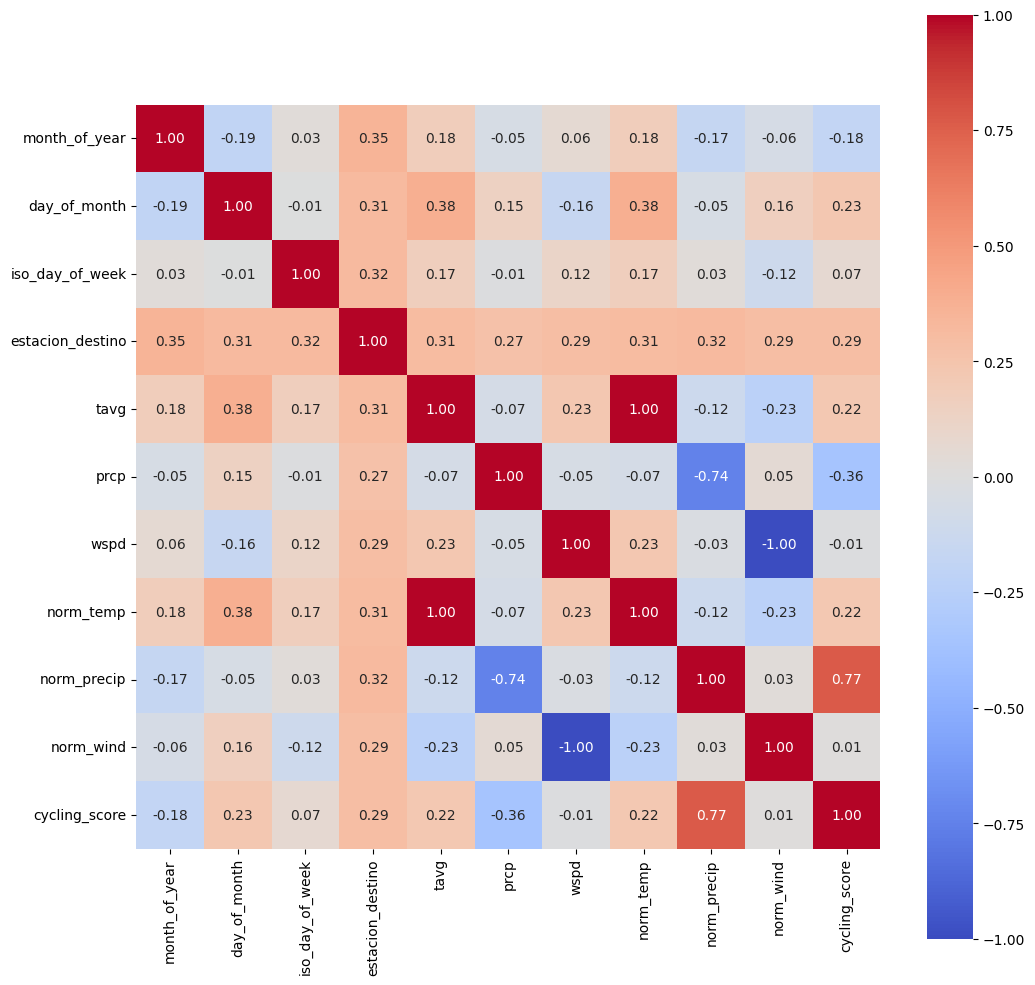

{'corr':                   month_of_year  day_of_month  iso_day_of_week  \
 month_of_year          1.000000     -0.190871         0.026725   
 day_of_month          -0.190871      1.000000        -0.005835   
 iso_day_of_week        0.026725     -0.005835         1.000000   
 estacion_destino       0.353536      0.312641         0.315389   
 tavg                   0.177609      0.384043         0.170953   
 prcp                  -0.050246      0.147321        -0.011761   
 wspd                   0.056239     -0.159924         0.117048   
 norm_temp              0.177609      0.384043         0.170953   
 norm_precip           -0.168926     -0.053564         0.030689   
 norm_wind             -0.056239      0.159924        -0.117048   
 cycling_score         -0.184162      0.230689         0.066277   
 
                   estacion_destino      tavg      prcp      wspd  norm_temp  \
 month_of_year             0.353536  0.177609 -0.050246  0.056239   0.177609   
 day_of_month             

In [33]:
associations(df, figsize=(12, 12), cmap='coolwarm')

Con esto, vemos que podemos eliminar algunas de las variables:
- tavg: la eliminamos en base a la temperatura normalizada
- prcp . idem
- wspd: idem

In [48]:
X = df.drop(columns="estacion_destino").copy()
y = df["estacion_destino"].copy()

In [55]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

def sin_transformer(period):
    return FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))

In [56]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, random_state=42)

# Normalizamos

In [57]:
X_train.columns

Index(['month_of_year', 'day_of_month', 'iso_day_of_week', 'hora', 'tavg',
       'prcp', 'wspd'],
      dtype='object')

In [64]:
# Assuming you have these periods for cyclical features
DAY_OF_MONTH_PERIOD = 31
DAY_OF_WEEK_PERIOD = 7
HOUR_PERIOD = 24


def sin_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.sin(x / period * 2 * np.pi))
    # Añadimos nombres de columnas manualmente
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_sin"]
    return transformer

def cos_transformer(period, col_name):
    transformer = FunctionTransformer(lambda x: np.cos(x / period * 2 * np.pi))
    transformer.get_feature_names_out = lambda input_features: [f"{col_name}_cos"]
    return transformer

# Create the column transformer
preprocessor = ColumnTransformer(
    transformers=[
        # One-hot encode month_of_year
        ('month_onehot', OneHotEncoder(), ['month_of_year']),
        
        # Transformaciones cíclicas (con nombres personalizados)
        ('day_of_month_sin', sin_transformer(31, "day_of_month"), ['day_of_month']),
        ('day_of_month_cos', cos_transformer(31, "day_of_month"), ['day_of_month']),
        
        ('day_of_week_sin', sin_transformer(7, "day_of_week"), ['iso_day_of_week']),
        ('day_of_week_cos', cos_transformer(7, "day_of_week"), ['iso_day_of_week']),
        
        ('hour_sin', sin_transformer(24, "hour"), ['hora']),
        ('hour_cos', cos_transformer(24, "hour"), ['hora']),
        
        # Standard scaling for tavg and wspd
        ('standard_scaler', StandardScaler(), ['tavg', 'wspd']),
        
        # MinMax scaling for prcp
        ('minmax_scaler', MinMaxScaler(), ['prcp'])
    ],
    remainder='drop'  # This will drop any columns not specified
)

# Create the full pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])


In [65]:
pipeline.fit(X_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('month_onehot',
                                                  OneHotEncoder(),
                                                  ['month_of_year']),
                                                 ('day_of_month_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000023C50CE13A0>),
                                                  ['day_of_month']),
                                                 ('day_of_month_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000023C51F54540...
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000023C51F54CC0>),
                                                  ['iso_day_of_week']),
                                                 ('hour_sin',
                                                  FunctionTransformer(func=<function sin_transformer.<locals>.<lambda> at 0x0000023C51F54D60>),
                                                  ['hora']),
                                                 ('hour_cos',
                                                  FunctionTransformer(func=<function cos_transformer.<locals>.<lambda> at 0x0000023C51F556C0>),
                                                  ['hora']),
                                                 ('standard_scaler',
                                                  StandardScaler(),
                                                  ['tavg', 'wspd']),
                                                 ('minmax_scaler',
                                                  MinMaxScaler(),
                                                  ['prcp'])]))])

In [66]:
X_train_transformed = pipeline.transform(X_train)
X_test_transformed = pipeline.transform(X_test)

In [68]:
X_train_transformed

array([[ 0.        ,  0.        ,  1.        , ...,  1.46035058,
         0.7557093 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -1.13114993,
         0.04697847,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., -0.93432711,
        -0.06205704,  0.        ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.11423201,
        -0.1165748 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  1.52595819,
         1.08281583,         nan],
       [ 0.        ,  0.        ,  0.        , ...,  1.26352776,
         1.30088686,  0.06896552]], shape=(1439, 13))

In [67]:
feature_names = pipeline.named_steps['preprocessor'].get_feature_names_out()

# 4. Convertir a DataFrame
X_train_transformed_df = pd.DataFrame(X_train_transformed, columns=feature_names)

AttributeError: Transformer day_of_month_sin (type FunctionTransformer) does not provide get_feature_names_out.

In [61]:
X_train_transformed

array([[ 0.        ,  0.        ,  1.        , ...,  1.46035058,
         0.7557093 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ..., -1.13114993,
         0.04697847,  0.        ],
       [ 0.        ,  0.        ,  1.        , ..., -0.93432711,
        -0.06205704,  0.        ],
       ...,
       [ 0.        ,  0.        ,  1.        , ..., -0.11423201,
        -0.1165748 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  1.52595819,
         1.08281583,         nan],
       [ 0.        ,  0.        ,  0.        , ...,  1.26352776,
         1.30088686,  0.06896552]], shape=(1439, 13))

In [ ]:
['month_of_year', 'day_of_month', 'iso_day_of_week', 'hora', 'tavg',
       'prcp', 'wspd']